In [1]:
# ===============================
# SUPPORT VECTOR MACHINE (SVM)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [2]:
# -------------------------------
# LOAD DATA
# -------------------------------
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')
df = pd.concat([red, white])

# Convert to binary classification
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# Features & target
X = df.drop('quality', axis=1)
y = df['quality']

In [3]:
# -------------------------------
# FEATURE SCALING
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# -------------------------------
# TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [5]:
# -------------------------------
# MODEL TRAINING (TUNED)
# -------------------------------
model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.1,
    probability=True,
    random_state=42
)

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
# -------------------------------
# PREDICTION
# -------------------------------
pred = model.predict(X_test)

In [7]:
# -------------------------------
# EVALUATION
# -------------------------------
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

Accuracy: 0.7807692307692308

Confusion Matrix:
 [[321 130]
 [155 694]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69       451
           1       0.84      0.82      0.83       849

    accuracy                           0.78      1300
   macro avg       0.76      0.76      0.76      1300
weighted avg       0.78      0.78      0.78      1300



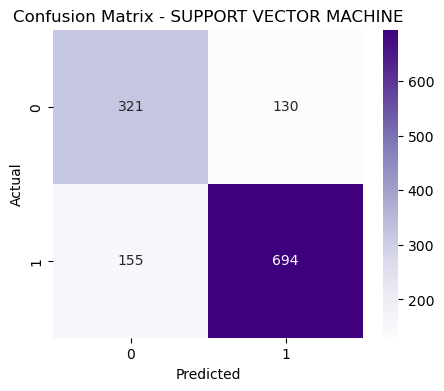

In [8]:
# -------------------------------
# CONFUSION MATRIX VISUALIZATION
# -------------------------------
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - SUPPORT VECTOR MACHINE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

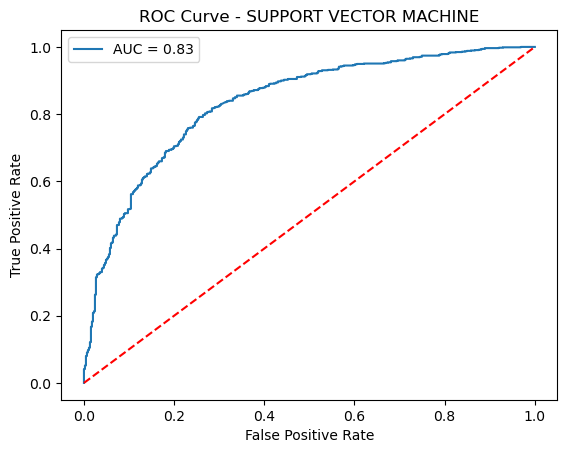

In [9]:
# -------------------------------
# ROC CURVE
# -------------------------------
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SUPPORT VECTOR MACHINE")
plt.legend()
plt.show()

In [10]:
# -------------------------------
# CROSS VALIDATION
# -------------------------------
scores = cross_val_score(model, X_scaled, y, cv=5)

print("\nCross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())


Cross Validation Scores: [0.49538462 0.64846154 0.72979215 0.76135489 0.74364896]
Average Accuracy: 0.6757284301533725


In [11]:
# -------------------------------
# SAVE RESULTS
# -------------------------------
pd.DataFrame({
    'Algorithm': ['SVM'],
    'Accuracy': [acc]
}).to_csv("svm.csv", index=False)

In [12]:
# -------------------------------
# CONCLUSION
# -------------------------------
print("\nModel evaluation completed successfully.")
print("Tuned SVM improves performance by optimizing hyperparameters.")
print("It effectively captures complex patterns in the dataset.")


Model evaluation completed successfully.
Tuned SVM improves performance by optimizing hyperparameters.
It effectively captures complex patterns in the dataset.
